In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r"..\Dataset\cmi_internet.csv")
df.shape

(8460, 82)

In [3]:
df.isna().sum()

id                                           0
Basic_Demos-Enroll_Season                    0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-Season                               1302
                                          ... 
SDS-SDS_Total_Raw                         3557
SDS-SDS_Total_T                           3557
PreInt_EduHx-Season                        389
PreInt_EduHx-computerinternet_hoursday     611
sii                                          0
Length: 82, dtype: int64

In [4]:
existing_counts = df.notna().sum()
print(existing_counts)

id                                        8460
Basic_Demos-Enroll_Season                 8460
Basic_Demos-Age                           8460
Basic_Demos-Sex                           8460
CGAS-Season                               7158
                                          ... 
SDS-SDS_Total_Raw                         4903
SDS-SDS_Total_T                           4903
PreInt_EduHx-Season                       8071
PreInt_EduHx-computerinternet_hoursday    7849
sii                                       8460
Length: 82, dtype: int64


### Analisi colonna binaria PRE Imputation

In [10]:
df["FGC-FGC_SRL"].value_counts().sum()

np.int64(6926)

In [ ]:
df["FGC-FGC_SRL_Zone"].value_counts().sum()

np.int64(6891)

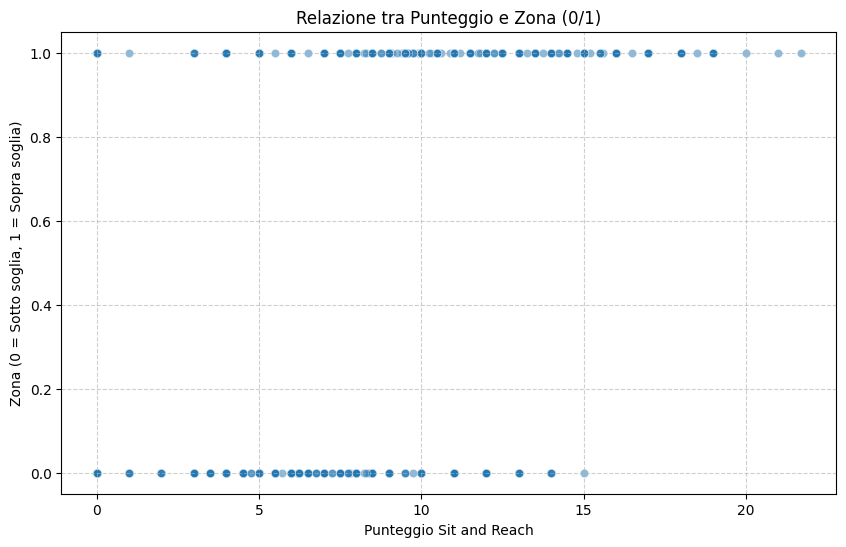

In [ ]:
# Lo scatter plot mostra come NON esista una soglia chiara per cui se FGC-FGC_SRL > soglia allora FGC-FGC_SRL_Zone = 1
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot base
plt.figure(figsize=(10, 6))
sns.scatterplot(x="FGC-FGC_SRL", y="FGC-FGC_SRL_Zone", data=df, alpha=0.5)

plt.title("Relazione tra Punteggio e Zona (0/1)")
plt.xlabel("Punteggio Sit and Reach")
plt.ylabel("Zona (0 = Sotto soglia, 1 = Sopra soglia)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Imputation

In [5]:
mask = df.notna().sum() > 4900
filtered_df = df.loc[:, mask]

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

def find_and_apply_best_imputation_final(df, k_folds=5):
    results = {}
    # 1. Create a copy of the dataframe to store our actual imputations
    df_imputed = df.copy() 
    
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    for target_col in numeric_cols:
        # Skip columns that don't actually have missing data
        if df_imputed[target_col].isna().sum() == 0:
            continue
            
        # Separate rows with data (for training) and rows without (for predicting)
        valid_mask = df_imputed[target_col].notna()
        missing_mask = df_imputed[target_col].isna()
        
        valid_data = df_imputed[valid_mask]
        
        # Campionamento (Using min() just in case a column has less than 4900 valid rows)
        n_sample = min(4900, len(valid_data))
        sample_data = valid_data.sample(n=n_sample, random_state=42)
        
        y_train = sample_data[target_col]
        X_train_raw = sample_data.drop(columns=[target_col])
        X_missing_raw = df_imputed[missing_mask].drop(columns=[target_col])
        
        # 2. Combine before get_dummies to ensure training and missing sets have identical columns
        X_combined = pd.concat([X_train_raw, X_missing_raw])
        X_combined_dummies = pd.get_dummies(X_combined, drop_first=True)
        
        # Split them back apart
        X_train = X_combined_dummies.iloc[:len(X_train_raw)]
        X_missing = X_combined_dummies.iloc[len(X_train_raw):]
        
        # Imputiamo eventuali NaN rimasti nelle feature predittive con la mediana
        imputer = SimpleImputer(strategy='median')
        X_train_imputed = imputer.fit_transform(X_train)
        X_missing_imputed = imputer.transform(X_missing) # Use transform() here, not fit_transform()
        
        # 3. Calcolo di K per il KNN
        k_neighbors = int(np.sqrt(len(X_train_imputed)))
        
        knn_pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('knn', KNeighborsRegressor(n_neighbors=k_neighbors))
        ])
        
        models = {
            'Linear Regression': LinearRegression(),
            'Decision Tree': DecisionTreeRegressor(random_state=42),
            f'KNN (k={k_neighbors})': knn_pipeline
        }
        
        best_r2 = -float('inf')
        best_method = ""
        best_model_instance = None
        
        # 4. Valutazione con K-Fold
        for name, model in models.items():
            scores = cross_val_score(model, X_train_imputed, y_train, cv=kf, scoring='r2')
            avg_r2 = np.mean(scores)
            
            if avg_r2 > best_r2:
                best_r2 = avg_r2
                best_method = name
                best_model_instance = model
        
        results[target_col] = {
            'Miglior Metodo': best_method, 
            'R2 Score': round(best_r2, 4)
        }
        
        # 5. NEW: Apply the changes if R2 is greater than 0
        if best_r2 > 0:
            # Fit the winning model on the complete training set
            best_model_instance.fit(X_train_imputed, y_train)
            
            # Predict the missing values
            predictions = best_model_instance.predict(X_missing_imputed)
            
            # Inject the predictions back into the copied dataframe
            df_imputed.loc[missing_mask, target_col] = predictions
            
            results[target_col]['Status'] = 'Imputed'
        else:
            results[target_col]['Status'] = 'Skipped (R2 <= 0)'
        
    return df_imputed, pd.DataFrame(results).T

# --- Utilizzo ---
# The function now returns TWO items: the newly filled dataframe, and the report.
filled_df, report = find_and_apply_best_imputation_final(filtered_df)

print(report)
# You can now use `filled_df` for your downstream tasks

                                           Miglior Metodo R2 Score  \
CGAS-CGAS_Score                                KNN (k=70)  -0.0156   
Physical-BMI                            Linear Regression   0.5498   
Physical-Height                         Linear Regression    0.684   
Physical-Weight                         Linear Regression   0.6581   
Physical-Waist_Circumference            Linear Regression   0.4131   
Physical-Diastolic_BP                   Linear Regression     0.21   
Physical-HeartRate                      Linear Regression    0.065   
Physical-Systolic_BP                    Linear Regression   0.3284   
Fitness_Endurance-Max_Stage             Linear Regression   0.1782   
Fitness_Endurance-Time_Mins             Linear Regression   0.2522   
Fitness_Endurance-Time_Sec              Linear Regression   0.0043   
FGC-FGC_CU                              Linear Regression   0.2913   
FGC-FGC_CU_Zone                         Linear Regression     0.18   
FGC-FGC_GSND        

### Colonne per cui R^2 è negativo

In [7]:
# Colonne per cui R^2 è negativo
non_imputed_cols = ['CGAS-CGAS_Score', 'BIA-BIA_BMC', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_LDM', 'BIA-BIA_SMM', 'BIA-BIA_TBW']

In [8]:
# Sostituisco i NaN con la mediana perché non è influenzata dagli outliers (forti in questi attributi)
for col in non_imputed_cols:
    median = filled_df[col].median()
    filled_df[col] = filled_df[col].fillna(median)

## **Categorical Attributes**

In [9]:
df_categorical = filtered_df.select_dtypes(include=['object', 'category'])
df_categorical.columns

C:\Users\nicco\AppData\Local\Temp\ipykernel_24888\211289734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categorical = filtered_df.select_dtypes(include=['object', 'category'])


Index(['Basic_Demos-Enroll_Season', 'CGAS-Season', 'Physical-Season',
       'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season',
       'PAQ_C-Season', 'SDS-Season', 'PreInt_EduHx-Season'],
      dtype='str')

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

def find_and_apply_best_categorical_imputation(df, categorical_cols, k_folds=5):
    results = {}
    # 1. Copia del dataframe per applicare l'imputazione
    df_imputed = df.copy() 
    
    # StratifiedKFold per bilanciare le classi nelle pieghe
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    for target_col in categorical_cols:
        # Salta se non ci sono valori mancanti
        if df_imputed[target_col].isna().sum() == 0:
            continue
            
        # Separa le righe con dati (training) e senza (da prevedere)
        valid_mask = df_imputed[target_col].notna()
        missing_mask = df_imputed[target_col].isna()
        
        valid_data = df_imputed[valid_mask]
        
        # Campionamento
        n_sample = min(4900, len(valid_data))
        sample_data = valid_data.sample(n=n_sample, random_state=42)
        
        y_train = sample_data[target_col]
        X_train_raw = sample_data.drop(columns=[target_col])
        X_missing_raw = df_imputed[missing_mask].drop(columns=[target_col])
        
        # 2. Combina prima del get_dummies per garantire l'allineamento delle colonne
        X_combined = pd.concat([X_train_raw, X_missing_raw])
        X_combined_dummies = pd.get_dummies(X_combined, drop_first=True)
        
        # Ri-dividi il dataset
        X_train = X_combined_dummies.iloc[:len(X_train_raw)]
        X_missing = X_combined_dummies.iloc[len(X_train_raw):]
        
        # Imputiamo eventuali NaN rimasti in X (usiamo la mediana visto che ora X è tutto numerico/dummy)
        imputer = SimpleImputer(strategy='median')
        X_train_imputed = imputer.fit_transform(X_train)
        X_missing_imputed = imputer.transform(X_missing)
        
        # 3. Calcolo di K per il KNN
        k_neighbors = int(np.sqrt(len(X_train_imputed)))
        
        knn_pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k_neighbors))
        ])
        
        models = {
            'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42),
            f'KNN (k={k_neighbors})': knn_pipeline
        }
        
        best_f1 = -float('inf')
        best_method = ""
        best_model_instance = None
        
        # 4. Valutazione con Stratified K-Fold
        for name, model in models.items():
            scores = cross_val_score(model, X_train_imputed, y_train, cv=skf, scoring='f1_weighted')
            avg_f1 = np.mean(scores)
            
            if avg_f1 > best_f1:
                best_f1 = avg_f1
                best_method = name
                best_model_instance = model
        
        results[target_col] = {
            'Miglior Metodo': best_method, 
            'F1 Score': round(best_f1, 4)
        }
        
        # 5. Applica le previsioni se il modello è valido (F1 > 0)
        if best_f1 > 0:
            # Fit del modello vincitore sull'intero train set
            best_model_instance.fit(X_train_imputed, y_train)
            
            # Previsione dei missing values
            predictions = best_model_instance.predict(X_missing_imputed)
            
            # Iniezione delle previsioni nel dataframe copiato
            df_imputed.loc[missing_mask, target_col] = predictions
            
            results[target_col]['Status'] = 'Imputed'
        else:
            results[target_col]['Status'] = 'Skipped (F1 <= 0)'
            
    return df_imputed, pd.DataFrame(results).T

# --- Utilizzo ---
colonne_categoriche_da_testare = df_categorical.columns.tolist()
filled_df_cat, report_cat = find_and_apply_best_categorical_imputation(filled_df, colonne_categoriche_da_testare)
print(report_cat)

                         Miglior Metodo F1 Score   Status
CGAS-Season                  KNN (k=70)   0.4642  Imputed
Physical-Season              KNN (k=70)    0.675  Imputed
Fitness_Endurance-Season  Decision Tree   0.6801  Imputed
FGC-Season                   KNN (k=70)   0.6601  Imputed
BIA-Season                   KNN (k=70)   0.6074  Imputed
PAQ_A-Season              Decision Tree   0.8394  Imputed
PAQ_C-Season                 KNN (k=70)   0.5724  Imputed
SDS-Season                   KNN (k=70)   0.6844  Imputed
PreInt_EduHx-Season          KNN (k=70)   0.8055  Imputed


## Check finale per vedere se sono stati trattati tutti gli attributi

In [11]:
for col in filled_df_cat.columns:
    if filled_df_cat[col].isna().sum() > 0:
        print(col, filled_df_cat[col].isna().sum())

## **Generazione nuovo dataset**

In [16]:
filled_df_cat.to_csv(r"Dataset\dataset_module_zero_DM2.csv", index=False)

In [17]:
filled_df_cat.shape
# Giusto che abbia 60 righe perché 22 sono state droppate (troppi missing values)

(8460, 60)

In [ ]:
count = 0
for col in df.columns:
    if df[col].notna().sum() < 4900: 
        count += 1
print(count)

22
